In [4]:
!unzip /content/IMDB Dataset (1).csv

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `unzip /content/IMDB Dataset (1).csv'


In [5]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset (1).csv")

In [6]:
df.head(2)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive


In [7]:
df.shape

(50000, 2)

Epoch 1
Train Loss: 0.7066 | Train Acc: 0.4929
Test Loss: 0.6698 | Test Acc: 0.6673
----------------------------------------
Epoch 2
Train Loss: 0.6053 | Train Acc: 0.7450
Test Loss: 0.6404 | Test Acc: 0.7698
----------------------------------------
Epoch 3
Train Loss: 0.5361 | Train Acc: 0.8196
Test Loss: 0.6057 | Test Acc: 0.8084
----------------------------------------
Epoch 4
Train Loss: 0.4834 | Train Acc: 0.8512
Test Loss: 0.5676 | Test Acc: 0.8265
----------------------------------------
Epoch 5
Train Loss: 0.4429 | Train Acc: 0.8690
Test Loss: 0.5284 | Test Acc: 0.8371
----------------------------------------
Epoch 6
Train Loss: 0.4098 | Train Acc: 0.8836
Test Loss: 0.4905 | Test Acc: 0.8477
----------------------------------------
Epoch 7
Train Loss: 0.3832 | Train Acc: 0.8942
Test Loss: 0.4557 | Test Acc: 0.8535
----------------------------------------
Epoch 8
Train Loss: 0.3608 | Train Acc: 0.9033
Test Loss: 0.4252 | Test Acc: 0.8588
----------------------------------------


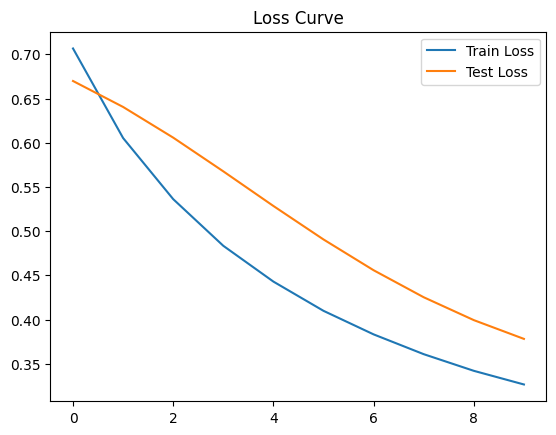

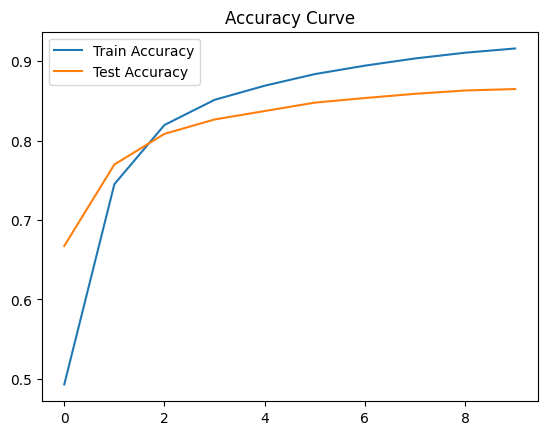


Enter a review (or type 'stop'): The ending was disappointing and confusing.
Prediction: Negative

Enter a review (or type 'stop'): I really loved this film. The characters were emotional and realistic.
Prediction: Positive

Enter a review (or type 'stop'): stop


In [9]:
# =========================
# 1) IMPORT LIBRARIES
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


# =========================
# 2) LOAD DATASET
# =========================
data = pd.read_csv("/content/IMDB Dataset (1).csv")

data = data.dropna()


# =========================
# 3) LABEL ENCODING
# =========================
le = LabelEncoder()
data["sentiment"] = le.fit_transform(data["sentiment"])
# positive = 1, negative = 0


# =========================
# 4) TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data["review"]).toarray()
y = data["sentiment"].values


# =========================
# 5) TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6) SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# convert to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)


# =========================
# 7) MLP MODEL
# =========================
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 1),
    nn.Sigmoid()
)


# =========================
# 8) LOSS + OPTIMIZER
# =========================
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# =========================
# 9) TRAINING LOOP
# =========================
epochs = 10

train_losses = []
test_losses = []
train_acc = []
test_acc = []

for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_preds = (outputs.detach().cpu().numpy() > 0.5).astype(int)
    train_accuracy = accuracy_score(y_train.cpu().numpy(), train_preds)

    # ---- TEST ----
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)

        test_preds = (test_outputs.cpu().numpy() > 0.5).astype(int)
        test_accuracy = accuracy_score(y_test.cpu().numpy(), test_preds)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_acc.append(train_accuracy)
    test_acc.append(test_accuracy)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Test Loss: {test_loss.item():.4f} | Test Acc: {test_accuracy:.4f}")
    print("-"*40)


# =========================
# 10) VISUALIZATION
# =========================
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


# =========================
# 11) USER PREDICTION
# =========================
def predict_sentiment(text):
    model.eval()

    vec = vectorizer.transform([text]).toarray()
    vec = scaler.transform(vec)
    vec = torch.FloatTensor(vec)

    with torch.no_grad():
        output = model(vec)


    if output.item() > 0.5:
        return "Positive"
    else:
        return "Negative"

# =========================
# 12) LIVE TEST
# =========================
while True:
    user_input = input("\nEnter a review (or type 'stop'): ")
    if user_input.lower() == "stop":
        break

    print("Prediction:", predict_sentiment(user_input))

In [10]:
# =========================
# EXPERIMENT 1- Tanh
# =========================

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.BatchNorm1d(128),
    nn.Tanh(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.Tanh(),

    nn.Linear(64, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):

    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_preds = (test_outputs > 0.5).float()
    acc_tanh = accuracy_score(y_test.numpy(), test_preds.numpy())

print("Experiment 1 (Tanh) Accuracy:", acc_tanh)

Experiment 1 (Tanh) Accuracy: 0.8615


In [11]:
# =========================
# EXPERIMENT 2 - Smaller Model + Different LR
# =========================

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),

    nn.Linear(32, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 10

for epoch in range(epochs):

    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_preds = (test_outputs > 0.5).float()
    acc_exp2= accuracy_score(y_test.numpy(), test_preds.numpy())

print("Experiment 2  (Different neurons + LR=0.0005) Accuracy:", acc_exp2)

Experiment 2  (Different neurons + LR=0.0005) Accuracy: 0.8276


In [12]:
results = pd.DataFrame({
    "Experiment": [
        "Tanh Activation",
        "Smaller Model + LR=0.0005"
    ],
    "Accuracy": [
        acc_tanh,
        acc_exp2
    ]
})

print(results)

                  Experiment  Accuracy
0            Tanh Activation    0.8615
1  Smaller Model + LR=0.0005    0.8276


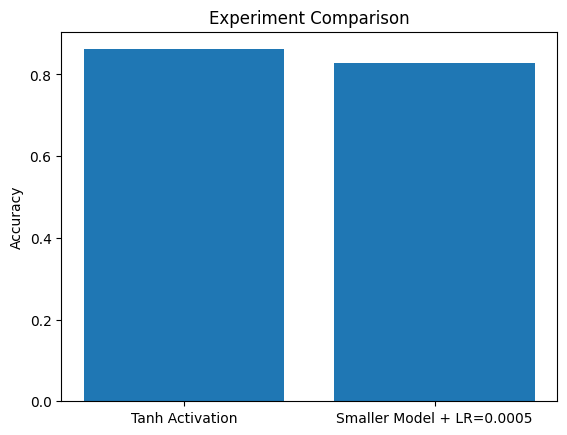

In [13]:
plt.bar(results["Experiment"], results["Accuracy"])
plt.title("Experiment Comparison")
plt.ylabel("Accuracy")
plt.show()